# Day 2 — Baseline + XGBoost

Goal: a trained, honestly-evaluated classifier with documented numbers, saved to `../src/model.joblib`.

Run top to bottom with **Shift+Enter**. Pick your **Python** kernel if asked.
Read curriculum sections 2–7 first — especially the evaluation section.

## Step 1 — load the Day 1 dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/trials_features.csv")
df["label"] = (df["overall_status"].str.upper() == "COMPLETED").astype(int)
print("Rows:", len(df))
print("Completion rate:", round(df["label"].mean(), 3))
df.head()

Rows: 155335
Completion rate: 0.814


,nct_id,phase,enrollment,number_of_arms,overall_status,start_year,duration_months,sponsor_class,allocation,intervention_model,masking,primary_purpose,n_conditions,n_interventions,brief_summary,label
0,NCT00000102,PHASE1/PHASE2,NaN,NaN,COMPLETED,NaN,NaN,NIH,NaN,PARALLEL,DOUBLE,TREATMENT,1,1,This study will test the ability of extended r...,1
1,NCT00000113,PHASE3,469.0,2.0,COMPLETED,1997.0,192.0,OTHER,RANDOMIZED,PARALLEL,TRIPLE,TREATMENT,1,2,To evaluate whether progressive addition lense...,1
2,NCT00000114,PHASE3,NaN,NaN,COMPLETED,1984.0,37.0,NIH,RANDOMIZED,FACTORIAL,DOUBLE,TREATMENT,1,2,To determine whether supplements of vitamin A ...,1
3,NCT00000115,PHASE2,NaN,NaN,COMPLETED,1990.0,42.0,NIH,RANDOMIZED,CROSSOVER,DOUBLE,TREATMENT,1,1,To test the efficacy of acetazolamide for the ...,1
4,NCT00000116,PHASE3,221.0,2.0,COMPLETED,1996.0,76.0,NIH,RANDOMIZED,PARALLEL,QUADRUPLE,TREATMENT,1,3,The purpose of this trial is to determine whet...,1


## Step 2 — define features and split

We drop `brief_summary` (that text is for Day 3 retrieval, not this tabular model) and `overall_status` (it IS the label — keeping it would be leakage).

In [2]:
from sklearn.model_selection import train_test_split

num = ["enrollment", "number_of_arms", "start_year", "duration_months",
       "n_conditions", "n_interventions"]
cat = ["phase", "sponsor_class", "allocation", "intervention_model",
       "masking", "primary_purpose"]

X = df[num + cat]
y = df["label"]
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", Xtr.shape, " Test:", Xte.shape)

Train: (124268, 12)  Test: (31067, 12)


## Step 3 — preprocessing pipeline

Imputation + scaling for numerics, imputation + one-hot for categoricals. Fitting inside a pipeline prevents leakage (transforms learn from train only).

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
])

## Step 4 — baseline: logistic regression

Always report a simple baseline so you can prove the fancy model earned its complexity.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

logit = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]).fit(Xtr, ytr)
print("Logistic Regression AUC:", round(roc_auc_score(yte, logit.predict_proba(Xte)[:, 1]), 4))

Logistic Regression AUC: 0.6784


## Step 5 — main model: XGBoost (with imbalance handling)

`scale_pos_weight` counteracts class imbalance so the model doesn't ignore the minority class (the failures). Value = (#negatives / #positives) on the training set.

In [5]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

spw = (ytr == 0).sum() / (ytr == 1).sum()   # auto-computed from your data
print("scale_pos_weight:", round(spw, 3))

model = Pipeline([("pre", pre),
    ("clf", xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="auc"))]).fit(Xtr, ytr)

proba = model.predict_proba(Xte)[:, 1]
print("\nXGBoost AUC:", round(roc_auc_score(yte, proba), 4))
print("\n", classification_report(yte, (proba > 0.5).astype(int)))

scale_pos_weight: 0.228

XGBoost AUC: 0.8551

               precision    recall  f1-score   support

           0       0.55      0.67      0.61      5771
           1       0.92      0.88      0.90     25296

    accuracy                           0.84     31067
   macro avg       0.74      0.78      0.75     31067
weighted avg       0.85      0.84      0.84     31067



## Step 6 — calibration check (high-signal extra)

Does "70% predicted" actually complete ~70% of the time? A model can rank well (good AUC) yet report poorly-calibrated probabilities.

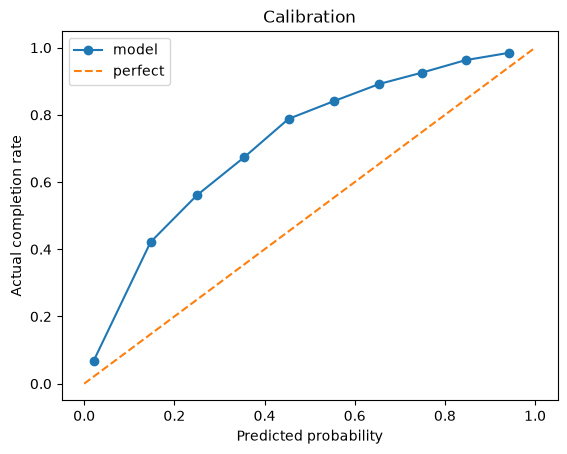

In [6]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

frac_pos, mean_pred = calibration_curve(yte, proba, n_bins=10)
plt.plot(mean_pred, frac_pos, marker="o", label="model")
plt.plot([0, 1], [0, 1], "--", label="perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Actual completion rate")
plt.title("Calibration"); plt.legend(); plt.show()

## Step 7 — feature importance with SHAP (gold for the CVS 'explain to stakeholders' angle)

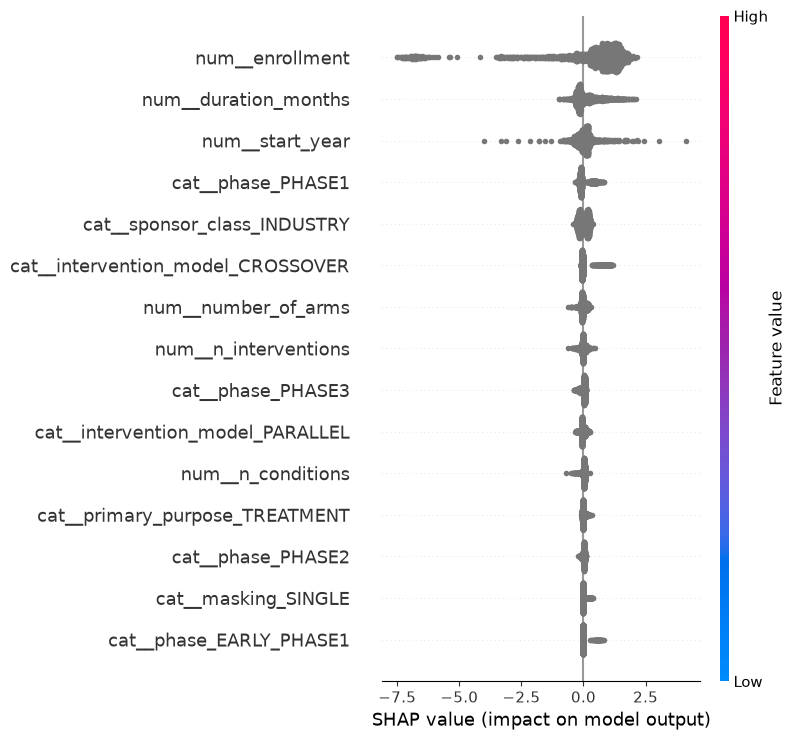

In [7]:
import shap

# transform a sample through the pipeline, then explain the XGBoost step
X_sample = Xte.sample(min(2000, len(Xte)), random_state=42)
X_trans = model.named_steps["pre"].transform(X_sample)
feat_names = model.named_steps["pre"].get_feature_names_out()

explainer = shap.TreeExplainer(model.named_steps["clf"])
shap_values = explainer.shap_values(X_trans)
shap.summary_plot(shap_values, X_trans, feature_names=feat_names, max_display=15)

## Step 8 — save the model for the API (Day 4 needs this)

In [8]:
import joblib
joblib.dump(model, "../src/model.joblib")
print("Saved ../src/model.joblib")

Saved ../src/model.joblib
